# Project: Portfolio Optimization Model
(Optimizing 20 Indian Stocks based on there last 5 year performance)

**Name** - Anuj Patel (22318)

**Class** - BFIA 5B

**Submitted to** - Dr. Satish Goel

In [6]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from datetime import datetime

In [7]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [27]:
from datetime import datetime, timedelta

end_date = datetime.today()
start_date = end_date.replace(year=end_date.year - 5)


In [28]:
INFY = yf.download('INFY.NS', start=start_date, end=end_date)  # Infosys
Reliance = yf.download('RELIANCE.NS', start=start_date, end=end_date)  # Reliance Industries
HDFC_Bank = yf.download('HDFCBANK.NS', start=start_date, end=end_date)  # HDFC Bank
ICICI_Bank = yf.download('ICICIBANK.NS', start=start_date, end=end_date)  # ICICI Bank
SBI = yf.download('SBIN.NS', start=start_date, end=end_date)  # State Bank of India
Bajaj_Finance = yf.download('BAJFINANCE.NS', start=start_date, end=end_date)  # Bajaj Finance
Bharti_Airtel = yf.download('BHARTIARTL.NS', start=start_date, end=end_date)  # Bharti Airtel
Kotak_Bank = yf.download('KOTAKBANK.NS', start=start_date, end=end_date)  # Kotak Mahindra Bank
L_T = yf.download('LT.NS', start=start_date, end=end_date)  # Larsen & Toubro
ITC = yf.download('ITC.NS', start=start_date, end=end_date)  # ITC Limited
Axis_Bank = yf.download('AXISBANK.NS', start=start_date, end=end_date)  # Axis Bank
Wipro = yf.download('WIPRO.NS', start=start_date, end=end_date)  # Wipro
Maruti = yf.download('MARUTI.NS', start=start_date, end=end_date)  # Maruti Suzuki
Asian_Paints = yf.download('ASIANPAINT.NS', start=start_date, end=end_date)  # Asian Paints
HCL_Tech = yf.download('HCLTECH.NS', start=start_date, end=end_date)  # HCL Technologies
UltraTech_Cement = yf.download('ULTRACEMCO.NS', start=start_date, end=end_date)  # UltraTech Cement
Sun_Pharma = yf.download('SUNPHARMA.NS', start=start_date, end=end_date)  # Sun Pharmaceutical
PowerGrid = yf.download('POWERGRID.NS', start=start_date, end=end_date)  # Power Grid Corporation
TCS = yf.download('TCS.NS', start=start_date, end=end_date)  # Tata Consultancy Services
HINDUNILVR = yf.download('HINDUNILVR.NS', start=start_date, end=end_date)  # Hindustan Unilever


/tmp/ipython-input-1601610842.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  INFY = yf.download('INFY.NS', start=start_date, end=end_date)  # Infosys
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1601610842.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  Reliance = yf.download('RELIANCE.NS', start=start_date, end=end_date)  # Reliance Industries
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1601610842.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  HDFC_Bank = yf.download('HDFCBANK.NS', start=start_date, end=end_date)  # HDFC Bank
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1601610842.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ICICI_Bank = yf.download('ICICIBANK.NS', start=start_date, end=end_date)  # ICI

In [29]:
stocks = pd.concat([
    INFY['Close'], Reliance['Close'], HDFC_Bank['Close'], # Changed 'Adj Close' to 'Close'
    ICICI_Bank['Close'], SBI['Close'], Bajaj_Finance['Close'], # Changed 'Adj Close' to 'Close'
    Bharti_Airtel['Close'], Kotak_Bank['Close'], L_T['Close'], # Changed 'Adj Close' to 'Close'
    ITC['Close'], Axis_Bank['Close'], Wipro['Close'], # Changed 'Adj Close' to 'Close'
    Maruti['Close'], Asian_Paints['Close'], HCL_Tech['Close'], # Changed 'Adj Close' to 'Close'
    UltraTech_Cement['Close'], Sun_Pharma['Close'], PowerGrid['Close'], # Changed 'Adj Close' to 'Close'
    TCS['Close'], HINDUNILVR['Close'] # Changed 'Adj Close' to 'Close'
], axis=1)

In [30]:
stocks

Ticker,INFY.NS,RELIANCE.NS,HDFCBANK.NS,ICICIBANK.NS,SBIN.NS,BAJFINANCE.NS,BHARTIARTL.NS,KOTAKBANK.NS,LT.NS,ITC.NS,AXISBANK.NS,WIPRO.NS,MARUTI.NS,ASIANPAINT.NS,HCLTECH.NS,ULTRACEMCO.NS,SUNPHARMA.NS,POWERGRID.NS,TCS.NS,HINDUNILVR.NS
Date,,,,,,,,,,,,,,,,,,,,
2021-02-11,1137.94604,932.11859,744.64581,609.95685,359.99789,545.32782,573.78613,390.56833,1452.35657,173.73466,737.02258,201.87198,7348.67725,2398.19263,793.31836,6253.53955,612.62646,91.24508,2818.32104,2081.06665
2021-02-12,1153.04358,925.72522,749.19226,626.35071,362.76602,546.34662,562.41779,388.58655,1443.67358,166.82977,747.27979,204.18173,7253.93604,2379.62354,785.14331,6224.44727,596.92175,90.77550,2804.95850,2061.34106
2021-02-15,1152.91150,921.64435,765.60211,651.83606,375.49951,566.17291,569.56500,395.53754,1459.14148,167.71207,790.69849,203.11925,7280.91553,2351.53027,780.44250,6234.66357,597.25488,90.69016,2760.16992,2037.11011
2021-02-16,1135.96545,933.84167,770.36169,636.74792,371.25500,564.25299,569.80481,402.24951,1470.33887,167.44353,771.82733,202.12605,7377.14307,2345.30908,778.52124,6283.36133,600.72894,96.28223,2732.87476,2019.54541
2021-02-17,1127.95435,944.61066,751.34698,635.78070,379.92853,558.85559,569.70886,396.23468,1469.29492,167.05994,774.51611,198.73073,7191.35010,2285.86816,771.08173,6245.80420,591.30609,98.20317,2701.49121,1989.93408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-05,1520.19995,1443.40002,949.70001,1396.50000,1073.50000,964.75000,1992.40002,408.75000,4063.30005,310.20001,1330.59998,233.39000,15059.00000,2432.10010,1610.00000,12773.00000,1702.59998,286.13776,2991.50000,2354.39990
2026-02-06,1507.09998,1450.80005,941.09998,1406.09998,1066.40002,981.70001,2038.40002,422.35001,4068.10010,325.79999,1341.59998,230.72000,14997.00000,2401.10010,1593.69995,12722.00000,1695.09998,289.50000,2941.60010,2424.19995
2026-02-09,1497.19995,1461.59998,937.25000,1396.30005,1146.00000,983.15002,2038.19995,428.79999,4113.60010,322.79999,1341.40002,230.08000,14978.00000,2417.39990,1602.00000,13048.00000,1704.59998,289.75000,2948.19995,2435.00000


In [31]:
stocks.columns = [
    'INFY', 'Reliance', 'HDFC_Bank', 'ICICI_Bank', 'SBI',
    'Bajaj_Finance', 'Bharti_Airtel', 'Kotak_Bank', 'L_T',
    'ITC', 'Axis_Bank', 'Wipro', 'Maruti', 'Asian_Paints',
    'HCL_Tech', 'UltraTech_Cement', 'Sun_Pharma', 'PowerGrid',
    'TCS', 'HINDUNILVR'
]
stocks

,INFY,Reliance,HDFC_Bank,ICICI_Bank,SBI,Bajaj_Finance,Bharti_Airtel,Kotak_Bank,L_T,ITC,Axis_Bank,Wipro,Maruti,Asian_Paints,HCL_Tech,UltraTech_Cement,Sun_Pharma,PowerGrid,TCS,HINDUNILVR
Date,,,,,,,,,,,,,,,,,,,,
2021-02-11,1137.94604,932.11859,744.64581,609.95685,359.99789,545.32782,573.78613,390.56833,1452.35657,173.73466,737.02258,201.87198,7348.67725,2398.19263,793.31836,6253.53955,612.62646,91.24508,2818.32104,2081.06665
2021-02-12,1153.04358,925.72522,749.19226,626.35071,362.76602,546.34662,562.41779,388.58655,1443.67358,166.82977,747.27979,204.18173,7253.93604,2379.62354,785.14331,6224.44727,596.92175,90.77550,2804.95850,2061.34106
2021-02-15,1152.91150,921.64435,765.60211,651.83606,375.49951,566.17291,569.56500,395.53754,1459.14148,167.71207,790.69849,203.11925,7280.91553,2351.53027,780.44250,6234.66357,597.25488,90.69016,2760.16992,2037.11011
2021-02-16,1135.96545,933.84167,770.36169,636.74792,371.25500,564.25299,569.80481,402.24951,1470.33887,167.44353,771.82733,202.12605,7377.14307,2345.30908,778.52124,6283.36133,600.72894,96.28223,2732.87476,2019.54541
2021-02-17,1127.95435,944.61066,751.34698,635.78070,379.92853,558.85559,569.70886,396.23468,1469.29492,167.05994,774.51611,198.73073,7191.35010,2285.86816,771.08173,6245.80420,591.30609,98.20317,2701.49121,1989.93408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-05,1520.19995,1443.40002,949.70001,1396.50000,1073.50000,964.75000,1992.40002,408.75000,4063.30005,310.20001,1330.59998,233.39000,15059.00000,2432.10010,1610.00000,12773.00000,1702.59998,286.13776,2991.50000,2354.39990
2026-02-06,1507.09998,1450.80005,941.09998,1406.09998,1066.40002,981.70001,2038.40002,422.35001,4068.10010,325.79999,1341.59998,230.72000,14997.00000,2401.10010,1593.69995,12722.00000,1695.09998,289.50000,2941.60010,2424.19995
2026-02-09,1497.19995,1461.59998,937.25000,1396.30005,1146.00000,983.15002,2038.19995,428.79999,4113.60010,322.79999,1341.40002,230.08000,14978.00000,2417.39990,1602.00000,13048.00000,1704.59998,289.75000,2948.19995,2435.00000


In [32]:
returns = stocks.pct_change()
returns = returns.dropna()  # Remove the first row with NaN values
returns

,INFY,Reliance,HDFC_Bank,ICICI_Bank,SBI,Bajaj_Finance,Bharti_Airtel,Kotak_Bank,L_T,ITC,Axis_Bank,Wipro,Maruti,Asian_Paints,HCL_Tech,UltraTech_Cement,Sun_Pharma,PowerGrid,TCS,HINDUNILVR
Date,,,,,,,,,,,,,,,,,,,,
2021-02-12,0.01327,-0.00686,0.00611,0.02688,0.00769,0.00187,-0.01981,-0.00507,-0.00598,-0.03974,0.01392,0.01144,-0.01289,-0.00774,-0.01030,-0.00465,-0.02564,-0.00515,-0.00474,-0.00948
2021-02-15,-0.00011,-0.00441,0.02190,0.04069,0.03510,0.03629,0.01271,0.01789,0.01071,0.00529,0.05810,-0.00520,0.00372,-0.01181,-0.00599,0.00164,0.00056,-0.00094,-0.01597,-0.01175
2021-02-16,-0.01470,0.01323,0.00622,-0.02315,-0.01130,-0.00339,0.00042,0.01697,0.00767,-0.00160,-0.02387,-0.00489,0.01322,-0.00265,-0.00246,0.00781,0.00582,0.06166,-0.00989,-0.00862
2021-02-17,-0.00705,0.01153,-0.02468,-0.00152,0.02336,-0.00957,-0.00017,-0.01495,-0.00071,-0.00229,0.00348,-0.01680,-0.02518,-0.02534,-0.00956,-0.00598,-0.01569,0.01995,-0.01148,-0.01466
2021-02-18,0.00870,-0.00746,-0.02030,-0.01932,0.00838,-0.02485,-0.00808,-0.02212,-0.01534,0.00505,-0.00096,0.00639,-0.00075,0.03459,0.00520,-0.01454,-0.00837,0.02804,-0.00513,-0.00788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-05,-0.01016,-0.00920,-0.00357,-0.00845,0.00496,0.00151,-0.01649,-0.00873,-0.00582,-0.01163,-0.00605,0.00021,-0.00080,-0.00840,-0.00728,-0.00258,0.00543,-0.00017,-0.00253,-0.00700
2026-02-06,-0.00862,0.00513,-0.00906,0.00687,-0.00661,0.01757,0.02309,0.03327,0.00118,0.05029,0.00827,-0.01144,-0.00412,-0.01275,-0.01012,-0.00399,-0.00441,0.01175,-0.01668,0.02965
2026-02-09,-0.00657,0.00744,-0.00409,-0.00697,0.07464,0.00148,-0.00010,0.01527,0.01118,-0.00921,-0.00015,-0.00277,-0.00127,0.00679,0.00521,0.02562,0.00560,0.00086,0.00224,0.00446


In [15]:
cumulative_return = (1+returns).cumprod()
cumulative_return

,INFY,Reliance,HDFC_Bank,ICICI_Bank,SBI,Bajaj_Finance,Bharti_Airtel,Kotak_Bank,L_T,ITC,Axis_Bank,Wipro,Maruti,Asian_Paints,HCL_Tech,UltraTech_Cement,Sun_Pharma,PowerGrid,TCS,HINDUNILVR
Date,,,,,,,,,,,,,,,,,,,,
2019-01-02,1.00601,0.98698,0.99088,1.00234,0.98097,0.98389,0.97856,0.99212,0.98863,0.99257,0.98844,0.99663,0.97205,1.00857,0.98594,0.99923,1.01499,0.97625,1.01077,0.99084
2019-01-03,1.00616,0.97480,0.98310,0.99863,0.97163,0.97341,0.98122,0.98784,0.96747,0.98638,0.96915,0.99648,0.96351,1.01221,0.98802,0.97278,1.00588,0.96525,0.99850,0.99295
2019-01-04,0.99399,0.98006,0.98573,1.00399,0.99349,0.96959,1.00923,0.99800,0.96265,0.99381,0.98773,0.99326,0.96759,1.01043,0.97135,0.97639,1.00058,0.97950,0.98636,0.98923
2019-01-07,1.01000,0.98550,0.98722,1.01086,0.98899,0.96114,1.01706,0.99692,0.95971,0.99629,1.01618,0.99265,0.98465,1.01783,0.98093,0.97943,0.99366,0.99225,0.99742,0.99103
2019-01-08,1.00752,0.98541,0.97900,1.04509,1.01903,0.95491,1.03052,0.98277,0.95860,1.00548,1.03762,0.99663,0.99501,1.02165,0.98469,0.97683,1.03344,0.98675,0.99514,0.98320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-05,2.74678,2.89554,1.88286,3.97912,3.88322,3.72197,7.10492,1.64212,3.13638,1.53674,2.13266,2.08110,2.14992,1.87805,4.20831,3.29311,4.22737,3.80503,1.89076,1.46463
2026-02-06,2.72311,2.91039,1.86581,4.00647,3.85754,3.78736,7.26896,1.69676,3.14009,1.61402,2.15029,2.05729,2.14106,1.85412,4.16571,3.27996,4.20875,3.84974,1.85922,1.50806
2026-02-09,2.70522,2.93205,1.85818,3.97855,4.14548,3.79296,7.26824,1.72267,3.17521,1.59916,2.14997,2.05159,2.13835,1.86670,4.18740,3.36401,4.23234,3.85307,1.86339,1.51477


In [33]:
equal_weights = np.repeat(1/len(stocks.columns), len(stocks.columns))
portfolio_returns = returns.dot(equal_weights)
cumulative_portfolio = (1 + portfolio_returns).cumprod()


In [34]:
portfolio = pd.DataFrame(cumulative_portfolio, columns=['TotalReturn'])
portfolio

,TotalReturn
Date,
2021-02-12,0.99616
2021-02-15,1.00554
2021-02-16,1.00687
2021-02-17,1.00046
2021-02-18,0.99752
...,...
2026-02-05,1.95387
2026-02-06,1.96356
2026-02-09,1.97630


In [35]:
mean_returns = returns.mean()
cov_matrix = returns.cov()


In [36]:
num_portfolios = 10000
results = np.zeros((3, num_portfolios))
weights_record = []

rf = 0.06   # Example 6% India risk-free
ann = 252

for i in range(num_portfolios):
    weights = np.random.random(len(stocks.columns))
    weights /= np.sum(weights)
    weights_record.append(weights)

    portfolio_return = np.sum(weights * mean_returns) * ann
    portfolio_stddev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(ann)

    sharpe_ratio = (portfolio_return - rf) / portfolio_stddev

    results[0, i] = portfolio_return
    results[1, i] = portfolio_stddev
    results[2, i] = sharpe_ratio


In [37]:
max_sharpe_idx = np.argmax(results[2])  # Index of max Sharpe ratio
optimal_weights = weights_record[max_sharpe_idx]


In [38]:

stock_names = stocks.columns
optimal_allocation = pd.DataFrame(optimal_weights, index=stock_names, columns=['Optimal Weight'])


print(optimal_allocation)



                  Optimal Weight
INFY                     0.00950
Reliance                 0.01724
HDFC_Bank                0.06610
ICICI_Bank               0.07587
SBI                      0.06100
Bajaj_Finance            0.02227
Bharti_Airtel            0.12550
Kotak_Bank               0.04505
L_T                      0.11784
ITC                      0.04600
Axis_Bank                0.00196
Wipro                    0.00534
Maruti                   0.03273
Asian_Paints             0.06196
HCL_Tech                 0.04051
UltraTech_Cement         0.05425
Sun_Pharma               0.09432
PowerGrid                0.10282
TCS                      0.00244
HINDUNILVR               0.01729


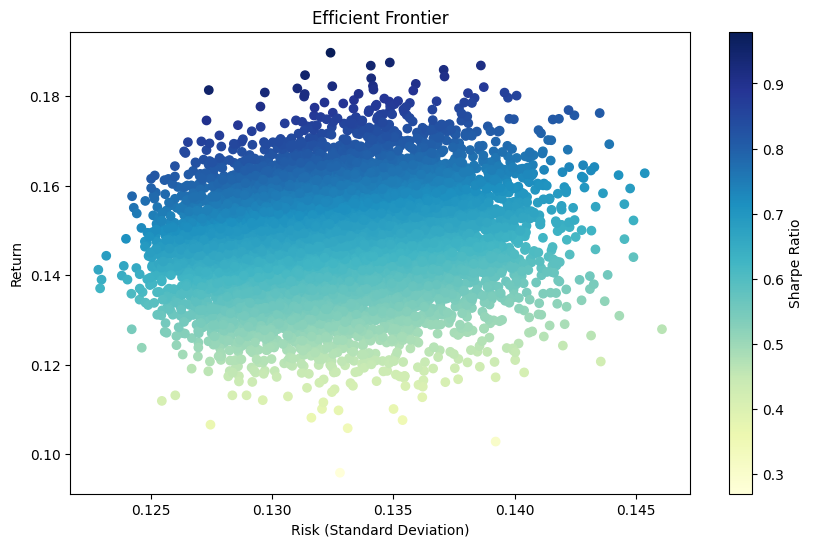

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(results[1, :], results[0, :], c=results[2, :], cmap='YlGnBu', marker='o')
plt.title('Efficient Frontier')
plt.xlabel('Risk (Standard Deviation)')
plt.ylabel('Return')
plt.colorbar(label='Sharpe Ratio')
plt.show()


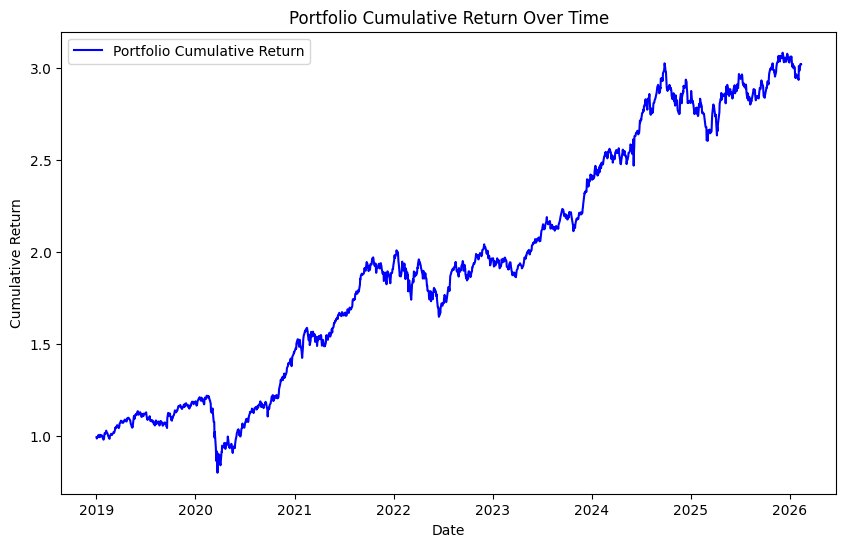

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(cumulative_return.index, total, label='Portfolio Cumulative Return', color='blue')
plt.title('Portfolio Cumulative Return Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

In [41]:
print(f"Optimal Portfolio Return: {results[0, max_sharpe_idx]:.2f}")
print(f"Optimal Portfolio Risk: {results[1, max_sharpe_idx]:.2f}")
print(f"Optimal Portfolio Sharpe Ratio: {results[2, max_sharpe_idx]:.2f}")


Optimal Portfolio Return: 0.19
Optimal Portfolio Risk: 0.13
Optimal Portfolio Sharpe Ratio: 0.98
